# ML Notebook — Cambodia Education Forecast (Updated)

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import RFE, SelectKBest, f_regression, mutual_info_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.svm import SVR
import xgboost as xgb


## 1. Load & Engineer Targets

In [22]:
import os
if os.path.exists('../data/cleaned_new_data.csv'):
    df = pd.read_csv('../data/cleaned_new_data.csv')
else:
    df = pd.read_csv('data/cleaned_new_data.csv')
df = df[df['Year'] != 2021].reset_index(drop=True)

# Targets
repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)

overage_cols = ['pct_overage_enrollment_primary',
                'pct_overage_enrollment_lower_sec',
                'pct_overage_enrollment_upper_sec']
df['over_age_enrollment_total'] = df[overage_cols].sum(axis=1)
df['avg_transition_rate'] = df[['transition_rate_lower_sec_total',
                                 'transition_rate_upper_sec_total']].mean(axis=1)

df['kids_population'] = df[['pop_aged6_total','pop_aged6_11_total',
                              'pop_aged12_14_total','pop_aged15_17_total']].sum(axis=1)
df['bad_qual_teacher']  = df[['teaching_staff_edu_primary',
                               'teaching_staff_edu_lower_sec',
                               'teaching_staff_edu_upper_sec']].sum(axis=1)
df['good_qual_teacher'] = df[['teaching_staff_edu_graduate',
                               'teaching_staff_edu_postgrad',
                               'teaching_staff_edu_phd']].sum(axis=1)

edu_levels = ['primary','lower_sec','upper_sec','graduate','postgrad','phd']
weights    = {'primary':1,'lower_sec':2,'upper_sec':3,'graduate':4,'postgrad':5,'phd':6}

df['no_pedagogy_ratio'] = (
    df[[f'teaching_staff_no_pedagogy_{l}' for l in edu_levels]].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)
df['teaching_high_qual_ratio'] = (
    df[['teaching_staff_edu_graduate','teaching_staff_edu_postgrad','teaching_staff_edu_phd']].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)
df['teaching_low_qual_ratio'] = (
    df[['teaching_staff_edu_primary','teaching_staff_edu_lower_sec','teaching_staff_edu_upper_sec']].sum(axis=1)
    / df['teaching_staff_total'].replace(0, pd.NA)
)

for prefix in ['teaching_staff_edu','non_teaching_staff_edu','teaching_staff_no_pedagogy']:
    weighted_sum = sum(df[f'{prefix}_{l}'] * w for l, w in weights.items())
    total = df[[f'{prefix}_{l}' for l in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f'{prefix}_qual_index'] = weighted_sum / total

print(df.shape)
print(df[['Year','enrollment_total','avg_dropout_rate','teaching_staff_edu_qual_index']].groupby('Year').mean().round(3))


(250, 276)
      enrollment_total  avg_dropout_rate  teaching_staff_edu_qual_index
Year                                                                   
2016         120385.44            14.182                          2.887
2017         123106.40            11.765                          2.936
2018         125730.08            10.903                          2.961
2019         127566.88            10.800                          3.010
2020         128411.40            13.247                          3.017
2022         130631.08            13.512                          3.099
2023         133770.48            12.585                          3.159
2024         136326.16            10.700                          3.190
2025         136928.20             9.753                          3.211
2026         128292.92             9.171                          3.286


## 2. Outlier Removal

In [23]:
def remove_outliers_iforest(df, contamination=0.05):
    numeric_df = df.select_dtypes(include=['number']).dropna()
    iso = IsolationForest(contamination=contamination, random_state=42)
    preds = iso.fit_predict(numeric_df)
    valid_indices  = numeric_df.index[preds ==  1]
    yeeted_indices = numeric_df.index[preds == -1]
    print(f'=== YEETED {len(yeeted_indices)} ROWS VIA ISOLATION FOREST ===')
    return df.loc[valid_indices].copy()

df = remove_outliers_iforest(df)
print(df.shape)


=== YEETED 13 ROWS VIA ISOLATION FOREST ===
(237, 276)


## 3. Feature Transformation

Based on scatter plot analysis per target.

In [24]:
def apply_transforms(df, feature_list, log_feats=(), sqrt_feats=(), drop_feats=()):
    """
    Apply tailored transforms based on scatter plot shapes.
    - log_feats  : right-skewed features  → log1p
    - sqrt_feats : curved features        → sqrt
    - drop_feats : no-pattern features    → dropped
    Returns (df_out, final_feature_list)
    """
    df_out = df.copy()
    final_feats = []
    active = [f for f in feature_list if f in df.columns and f not in drop_feats]

    for f in active:
        if f in log_feats:
            col = f'log_{f}'
            df_out[col] = np.log1p(df_out[f])
            final_feats.append(col)
        elif f in sqrt_feats:
            col = f'sqrt_{f}'
            df_out[col] = np.sqrt(df_out[f])
            final_feats.append(col)
        else:
            final_feats.append(f)

    return df_out, final_feats


# ── Dropout features (from scatter: Image 1) ─────────────────────────────────
# Drop  : schools_in_pagoda_lycee (flat), funding_abroad (flat), no_pedagogy_ratio (flat)
# log1p : buildings_repaired (extreme left pile at 0)
# sqrt  : buildings_per_school (slight curve)
# linear: the rest

raw_dropout_features = [
    'buildings_repaired',          # log1p → right skew
    'over_age_enrollment_total',   # linear positive
    'staff_per_school',            # linear negative
    'buildings_per_school',        # sqrt → slight curve
    'gross_admission_rate_total',  # linear positive
    'avg_transition_rate',         # strong negative linear
    'teaching_staff_edu_qual_index', # negative linear
]

df, features_dropout = apply_transforms(
    df,
    raw_dropout_features,
    log_feats  = ['buildings_repaired'],
    sqrt_feats = ['buildings_per_school'],
    drop_feats = ['schools_in_pagoda_lycee', 'funding_abroad', 'no_pedagogy_ratio'],
)
print('Dropout features:', features_dropout)


# ── Teacher qual features (from scatter: Image 2) ────────────────────────────
# Drop  : pb_fund_per_student_riel (outlier destroying line)
# log1p : schools_without_water, schools_without_latrine,
#          principal_upper_sec_plus_edu, buildings_poor_roof, pb_fund_per_school_riel
# sqrt  : classrooms_per_school
# linear: principal_avg_service_years, gross_admission_rate_total, transition_rate_lower_sec_total

raw_teacher_features = [
    'schools_without_water',          # log1p
    'schools_without_latrine',        # log1p
    'principal_avg_service_years',    # linear
    'principal_upper_sec_plus_edu',   # log1p
    'buildings_poor_roof',            # log1p
    'pb_fund_per_school_riel',        # log1p
    'classrooms_per_school',          # sqrt
    'gross_admission_rate_total',     # linear negative
    'transition_rate_lower_sec_total', # linear positive
]

df, features_teacher = apply_transforms(
    df,
    raw_teacher_features,
    log_feats  = ['schools_without_water', 'schools_without_latrine',
                  'principal_upper_sec_plus_edu', 'buildings_poor_roof',
                  'pb_fund_per_school_riel'],
    sqrt_feats = ['classrooms_per_school'],
    drop_feats = ['pb_fund_per_student_riel'],
)
print('Teacher features:', features_teacher)


# ── Enrollment features (unchanged) ─────────────────────────────────────────
features_enrollment = ['total_staff_total', 'kids_population', 'num_classrooms']
print('Enrollment features:', features_enrollment)


Dropout features: ['log_buildings_repaired', 'over_age_enrollment_total', 'staff_per_school', 'sqrt_buildings_per_school', 'gross_admission_rate_total', 'avg_transition_rate', 'teaching_staff_edu_qual_index']
Teacher features: ['log_schools_without_water', 'log_schools_without_latrine', 'principal_avg_service_years', 'log_principal_upper_sec_plus_edu', 'log_buildings_poor_roof', 'log_pb_fund_per_school_riel', 'sqrt_classrooms_per_school', 'gross_admission_rate_total', 'transition_rate_lower_sec_total']
Enrollment features: ['total_staff_total', 'kids_population', 'num_classrooms']


## 4. Feature Selection

In [25]:
def select_features(df, target_col, features_all, k_num=10, log_transform=False):
    """
    3-method feature selection: ANOVA F, Mutual Info, RFE.
    Returns union, intersection, and individual results.
    """
    y = df[target_col].copy()
    if log_transform:
        y = np.log1p(y)

    valid_features = [f for f in features_all if f in df.columns]
    X = df[valid_features].fillna(np.nan)
    imputer = SimpleImputer(strategy='median')
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=valid_features)

    results = {}

    anova_sel = SelectKBest(score_func=f_regression, k=min(k_num, len(valid_features))).fit(X_imp, y)
    results['anova'] = list(X_imp.columns[anova_sel.get_support()])

    mi_sel = SelectKBest(score_func=mutual_info_regression, k=min(k_num, len(valid_features))).fit(X_imp, y)
    results['mutual_info'] = list(X_imp.columns[mi_sel.get_support()])

    estimator = RandomForestRegressor(random_state=42, n_jobs=-1)
    rfe_sel = RFE(estimator=estimator, n_features_to_select=min(k_num, len(valid_features)), step=2)
    rfe_sel.fit(X_imp, y)
    results['rfe'] = list(X_imp.columns[rfe_sel.support_])

    results['common_features'] = sorted(set(results['anova']) & set(results['mutual_info']) & set(results['rfe']))
    results['union_features']  = sorted(set(results['anova']) | set(results['mutual_info']) | set(results['rfe']))
    results['X_pure'] = X_imp
    results['y'] = y
    return results


sel_dropout    = select_features(df, 'avg_dropout_rate',              features_dropout,    k_num=6, log_transform=True)
sel_teacher    = select_features(df, 'teaching_staff_edu_qual_index', features_teacher,    k_num=6)
sel_enrollment = select_features(df, 'enrollment_total',              features_enrollment, k_num=3)

print('Dropout    union:', sel_dropout['union_features'])
print('Teacher    union:', sel_teacher['union_features'])
print('Enrollment union:', sel_enrollment['union_features'])


Dropout    union: ['avg_transition_rate', 'gross_admission_rate_total', 'log_buildings_repaired', 'over_age_enrollment_total', 'sqrt_buildings_per_school', 'staff_per_school', 'teaching_staff_edu_qual_index']
Teacher    union: ['gross_admission_rate_total', 'log_buildings_poor_roof', 'log_pb_fund_per_school_riel', 'log_principal_upper_sec_plus_edu', 'log_schools_without_latrine', 'log_schools_without_water', 'principal_avg_service_years', 'sqrt_classrooms_per_school', 'transition_rate_lower_sec_total']
Enrollment union: ['kids_population', 'num_classrooms', 'total_staff_total']


## 5. Project Features to 2030

In [26]:
def _fit_candidates(x, y):
    x = np.array(x, dtype=float)
    y = np.array(y, dtype=float)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 3:
        return 'linear', None, -999

    candidates = {}

    X_lin = x.reshape(-1, 1)
    m = LinearRegression().fit(X_lin, y)
    candidates['linear'] = (m, lambda xf: m.predict(xf.reshape(-1,1)), r2_score(y, m.predict(X_lin)))

    if np.all(x > 0):
        X_log = np.log(x).reshape(-1, 1)
        m2 = LinearRegression().fit(X_log, y)
        candidates['log'] = (m2, lambda xf: m2.predict(np.log(xf).reshape(-1,1)), r2_score(y, m2.predict(X_log)))

    if np.all(x >= 0):
        X_sqrt = np.sqrt(x).reshape(-1, 1)
        m3 = LinearRegression().fit(X_sqrt, y)
        candidates['sqrt'] = (m3, lambda xf: m3.predict(np.sqrt(xf).reshape(-1,1)), r2_score(y, m3.predict(X_sqrt)))

    if np.all(y > 0):
        X_exp = x.reshape(-1, 1)
        m4 = LinearRegression().fit(X_exp, np.log(y))
        y_pred_exp = np.exp(m4.predict(X_exp))
        candidates['exp'] = (m4, lambda xf: np.exp(m4.predict(xf.reshape(-1,1))), r2_score(y, y_pred_exp))

    best_name = max(candidates, key=lambda k: candidates[k][2])
    _, pred_fn, best_r2 = candidates[best_name]
    return best_name, pred_fn, best_r2


def project_features_to_2030(df, feature_list, year_col='Year', target_years=None, r2_threshold=0.5):
    if target_years is None:
        target_years = [2027, 2028, 2029, 2030]

    # use RAW column names (before transform) for projection, then re-apply transforms
    national = df.groupby(year_col)[feature_list].mean().reset_index()
    projected_rows = {year_col: target_years}
    summary = []

    for feat in feature_list:
        if feat not in national.columns:
            print(f'  [skip] {feat} not in dataframe')
            continue

        x_train   = national[year_col].values
        y_train   = national[feat].values
        x_fore    = np.array(target_years, dtype=float)
        hist_mean = float(np.nanmean(y_train))

        best_name, pred_fn, best_r2 = _fit_candidates(x_train, y_train)

        if pred_fn is None or best_r2 < r2_threshold:
            projected_rows[feat] = [hist_mean] * len(target_years)
            label = 'flat (low R²)' if pred_fn is not None else 'flat (no data)'
            summary.append({'feature': feat, 'best_fit': label,
                            'r2': round(best_r2, 4) if pred_fn else np.nan,
                            'projected_as': f'mean={hist_mean:.4f}'})
            continue

        projected_rows[feat] = list(pred_fn(x_fore))
        summary.append({'feature': feat, 'best_fit': best_name,
                        'r2': round(best_r2, 4), 'projected_as': 'trend'})

    projected_df = pd.DataFrame(projected_rows)
    fit_summary  = pd.DataFrame(summary).sort_values('r2', ascending=False).reset_index(drop=True)
    return projected_df, fit_summary


# Collect all RAW feature names (before log/sqrt prefix was added)
raw_all = list(set(
    raw_dropout_features + raw_teacher_features + features_enrollment
))

projected_df, fit_summary = project_features_to_2030(df, raw_all)

# Re-apply transforms to projected_df so column names match features_dropout / features_teacher
projected_df, _ = apply_transforms(
    projected_df, raw_dropout_features,
    log_feats  = ['buildings_repaired'],
    sqrt_feats = ['buildings_per_school'],
    drop_feats = ['schools_in_pagoda_lycee','funding_abroad','no_pedagogy_ratio'],
)
projected_df, _ = apply_transforms(
    projected_df, raw_teacher_features,
    log_feats  = ['schools_without_water','schools_without_latrine',
                  'principal_upper_sec_plus_edu','buildings_poor_roof','pb_fund_per_school_riel'],
    sqrt_feats = ['classrooms_per_school'],
    drop_feats = ['pb_fund_per_student_riel'],
)

print('\n=== Fit summary ===')
print(fit_summary.to_string(index=False))
print('\n=== Projected values (2027-2030) ===')
print(projected_df.to_string(index=False))


=== Fit summary ===
                        feature      best_fit     r2     projected_as
  teaching_staff_edu_qual_index           exp 0.9828            trend
    principal_avg_service_years           exp 0.9465            trend
        pb_fund_per_school_riel           log 0.8315            trend
        schools_without_latrine           exp 0.7702            trend
            avg_transition_rate           log 0.6844            trend
     gross_admission_rate_total           exp 0.6419            trend
            buildings_poor_roof           log 0.5851            trend
                 num_classrooms flat (low R²) 0.4550   mean=2763.6723
          schools_without_water flat (low R²) 0.4518    mean=331.2626
   principal_upper_sec_plus_edu flat (low R²) 0.3878    mean=325.4547
          classrooms_per_school flat (low R²) 0.3878      mean=5.3725
transition_rate_lower_sec_total flat (low R²) 0.3831     mean=84.7998
                kids_population flat (low R²) 0.3254 mean=159173.4184

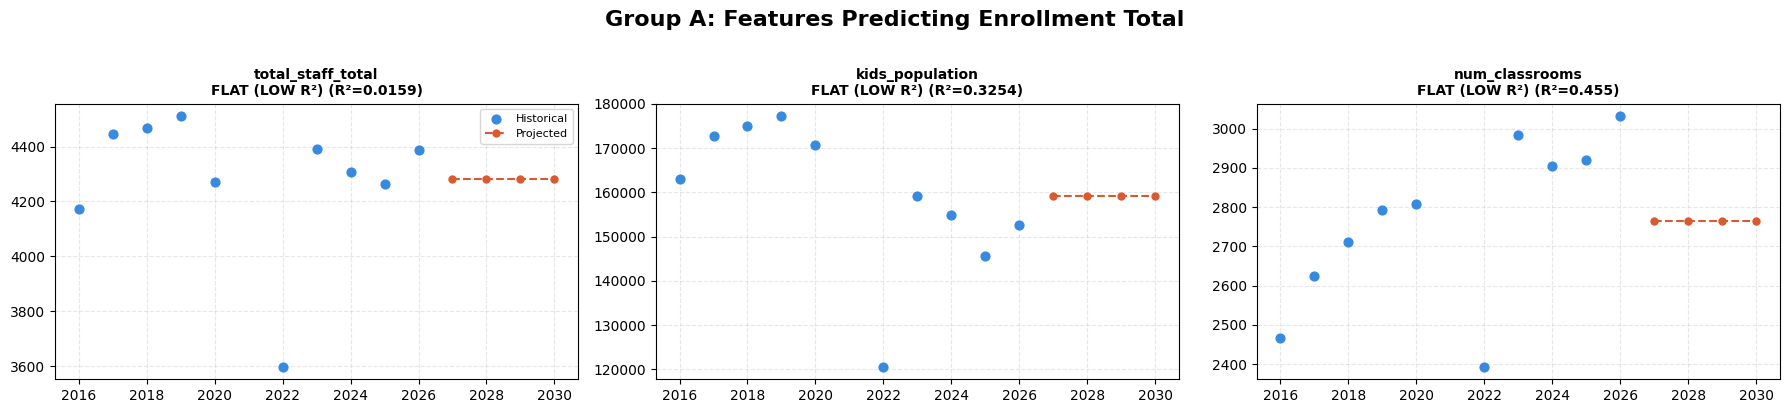

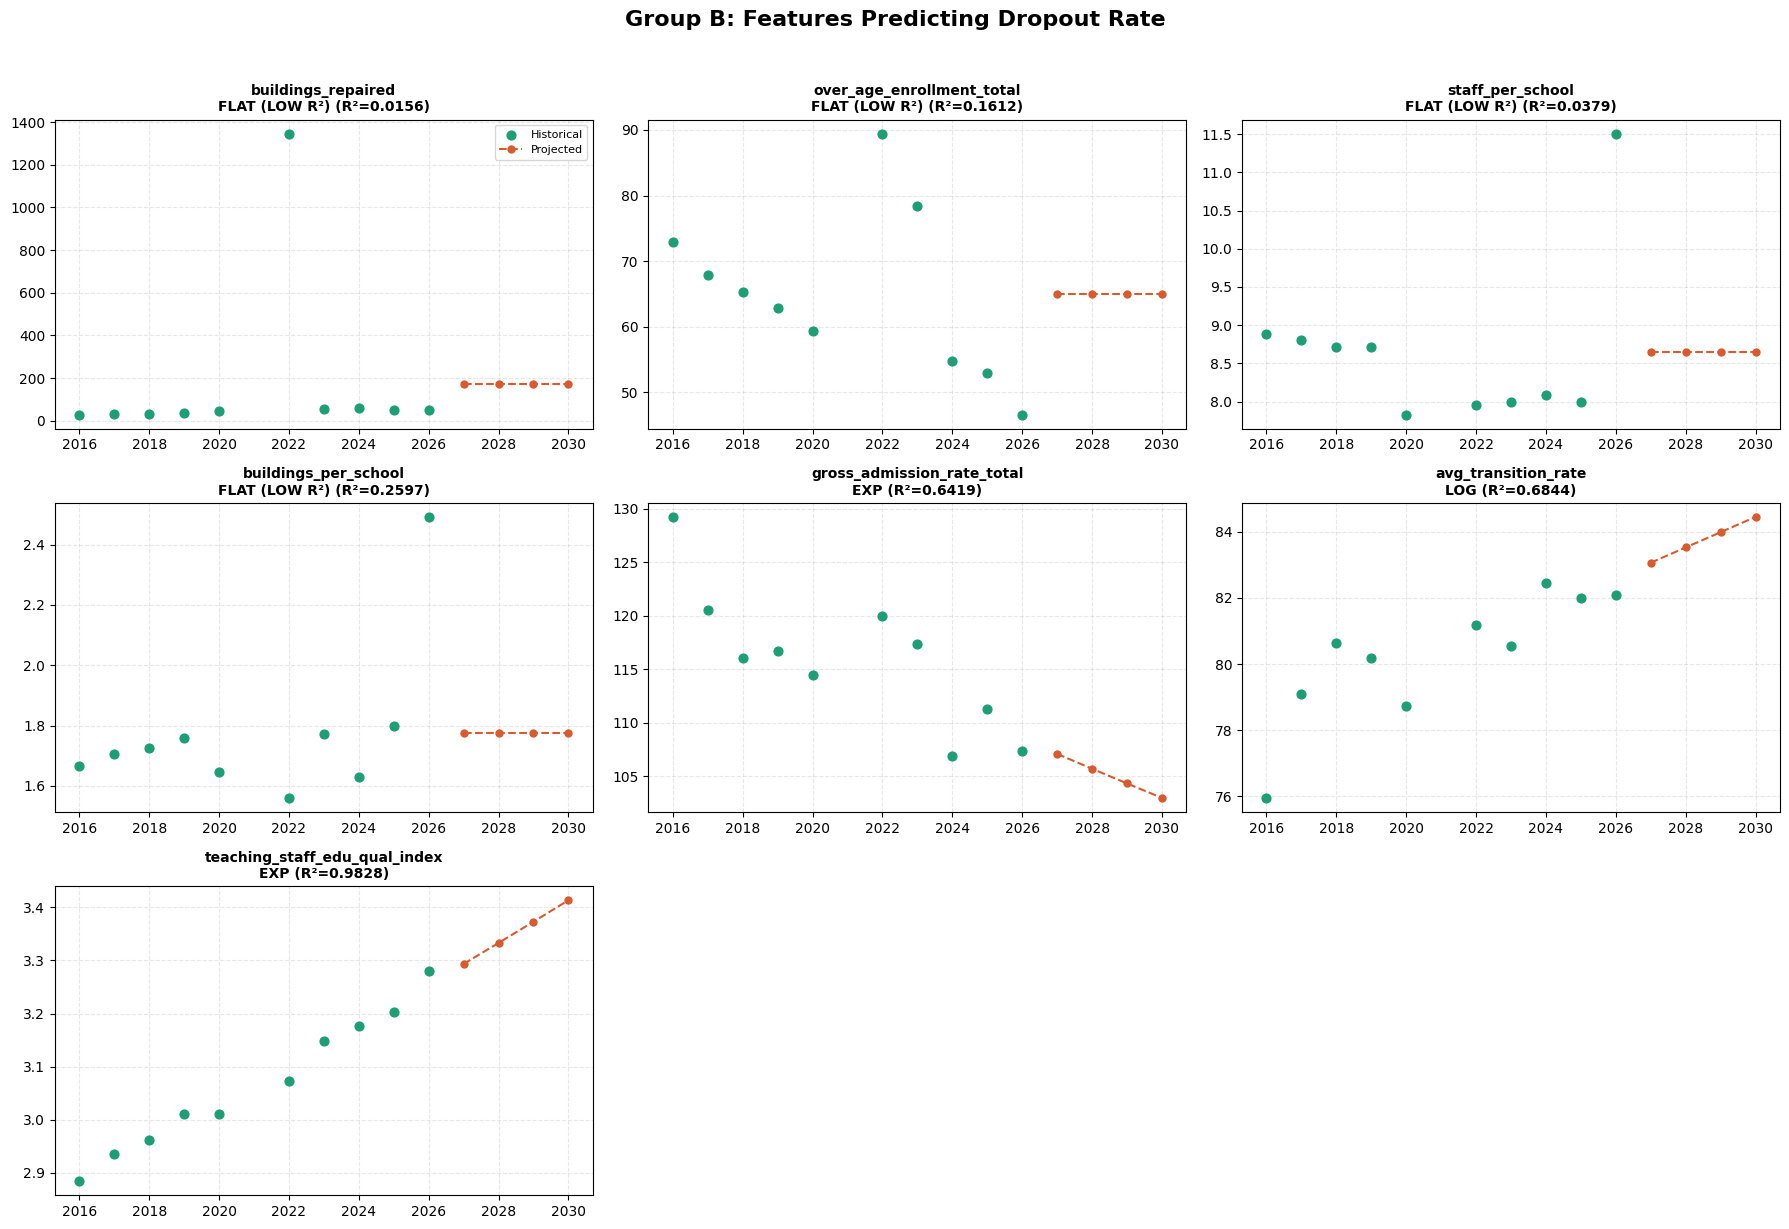

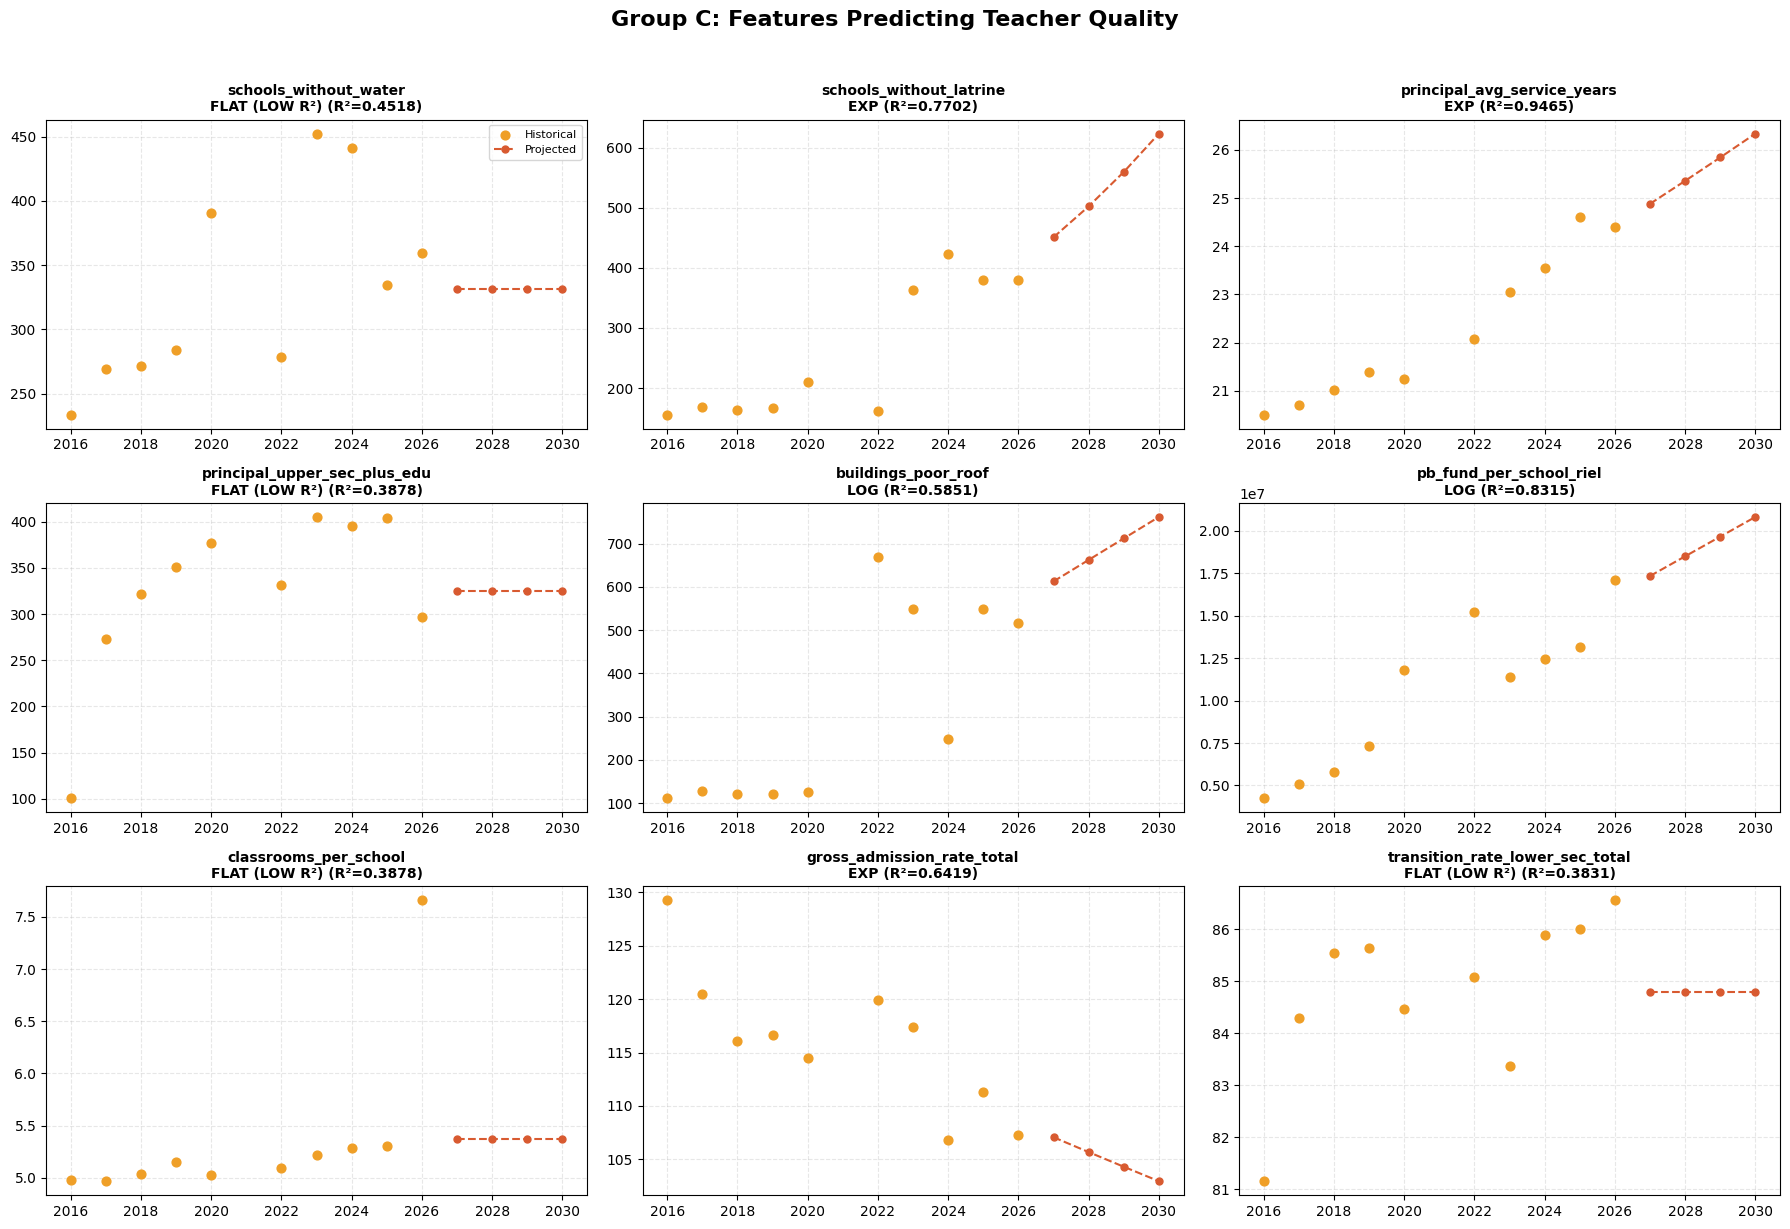

C:\Users\ASUS_PC\AppData\Local\Temp\ipykernel_21128\22186153.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fit_summary.sort_values('r2', ascending=False), x='r2', y='feature', palette='viridis')


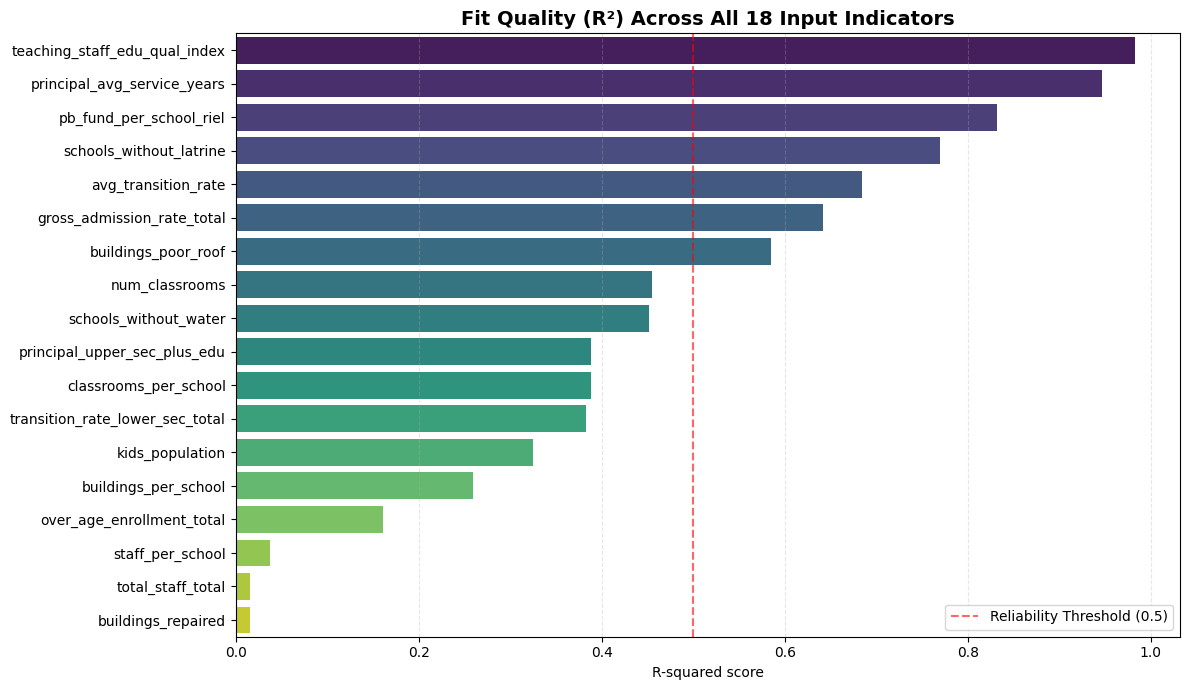

In [27]:
# ── Visualize All 18 Features Grouped by Target ─────────────────────────────
import textwrap

def plot_feature_group(title, features, color_hist='#378ADD', color_proj='#D85A30'):
    # Filter to only unique features in this group that exist in data
    unique_feats = [f for f in features if f in national.columns]
    n_feats = len(unique_feats)
    if n_feats == 0: return
    
    rows = (n_feats + 2) // 3
    fig, axes = plt.subplots(rows, 3, figsize=(18, 4 * rows))
    axes = axes.flatten()
    
    for i, feat in enumerate(unique_feats):
        ax = axes[i]
        # Historical
        ax.scatter(national['Year'], national[feat], color=color_hist, s=40, label='Historical', zorder=3)
        # Projected
        ax.plot(projected_df['Year'], projected_df[feat], color=color_proj, marker='o', markersize=5, 
                linestyle='--', linewidth=1.5, label='Projected', zorder=3)
        
        # Fit Summary Info
        summary_row = fit_summary[fit_summary['feature'] == feat]
        if not summary_row.empty:
            row = summary_row.iloc[0]
            info = f"{row['best_fit'].upper()} (R²={row['r2']})" if row['r2'] > -1 else row['best_fit']
        else:
            info = "No summary"
            
        ax.set_title(f"{textwrap.fill(feat, 35)}\n{info}", fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.3)
        if i == 0: ax.legend(fontsize=8)
    
    # Hide unused axes
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

national = df.groupby('Year')[raw_all].mean().reset_index()

# 1. Enrollment Features
plot_feature_group("Group A: Features Predicting Enrollment Total", features_enrollment)

# 2. Dropout Features
plot_feature_group("Group B: Features Predicting Dropout Rate", raw_dropout_features, color_hist='#1D9E75')

# 3. Teacher Quality Features
plot_feature_group("Group C: Features Predicting Teacher Quality", raw_teacher_features, color_hist='#EF9F27')

# 4. Fit Quality Summary (All 18)
plt.figure(figsize=(12, 7))
sns.barplot(data=fit_summary.sort_values('r2', ascending=False), x='r2', y='feature', palette='viridis')
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.6, label='Reliability Threshold (0.5)')
plt.title('Fit Quality (R²) Across All 18 Input Indicators', fontsize=14, fontweight='bold')
plt.xlabel('R-squared score')
plt.ylabel('')
plt.legend()
plt.grid(True, axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Select Best Model & Forecast 2027–2030

In [28]:
def select_and_forecast(df, projected_df, target, features,
                         train_years=(2016, 2023), val_years=(2024, 2026),
                         log_transform=False):
    """
    1. Train all 7 models on train_years, evaluate on val_years.
    2. Print R², RMSE, MAE for all models.
    3. Pick best by R².
    4. Retrain on full real data (train + val).
    5. Predict on projected 2027-2030.
    6. Plot: metrics + historical + forecast.
    """
    feats = [c for c in features if c in df.columns and c in projected_df.columns]

    train_mask = df['Year'].between(*train_years)
    val_mask   = df['Year'].between(*val_years)

    X_train_raw = df.loc[train_mask, feats]
    X_val_raw   = df.loc[val_mask,   feats]
    y_train     = df.loc[train_mask, target]
    y_val       = df.loc[val_mask,   target]

    imputer     = SimpleImputer(strategy='median')
    X_train_imp = pd.DataFrame(imputer.fit_transform(X_train_raw), columns=feats)
    X_val_imp   = pd.DataFrame(imputer.transform(X_val_raw),       columns=feats)

    scaler      = StandardScaler()
    X_train_sc  = scaler.fit_transform(X_train_imp)
    X_val_sc    = scaler.transform(X_val_imp)

    y_fit = np.log1p(y_train.values) if log_transform else y_train.values

    models = {
        'Random Forest':     (RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1), X_train_imp, X_val_imp),
        'Gradient Boosting': (GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),         X_train_imp, X_val_imp),
        'XGBoost':           (xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),     X_train_imp, X_val_imp),
        'SVR (RBF)':         (SVR(kernel='rbf',    C=10, epsilon=0.1),                                                               X_train_sc,  X_val_sc),
        'SVR (Linear)':      (SVR(kernel='linear', C=1),                                                                             X_train_sc,  X_val_sc),
        'Ridge':             (Ridge(alpha=1.0),                                                                                      X_train_imp, X_val_imp),
        'Lasso':             (Lasso(alpha=0.01, max_iter=5000),                                                                      X_train_imp, X_val_imp),
    }

    records, val_preds = [], {}
    for name, (model, X_tr, X_v) in models.items():
        model.fit(X_tr, y_fit)
        raw    = model.predict(X_v)
        y_pred = np.expm1(raw) if log_transform else raw
        records.append({'Model': name,
                        'R²':   round(r2_score(y_val, y_pred), 4),
                        'RMSE': round(np.sqrt(mean_squared_error(y_val, y_pred)), 4),
                        'MAE':  round(mean_absolute_error(y_val, y_pred), 4)})
        val_preds[name] = y_pred

    results_df = pd.DataFrame(records).sort_values('R²', ascending=False).reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"  TARGET: {target}  |  Val: {val_years[0]}–{val_years[1]}")
    print(f"{'='*60}")
    print(results_df.to_string(index=False))
    print(f"{'='*60}")

    best_name = results_df.iloc[0]['Model']
    best_r2   = results_df.iloc[0]['R²']
    print(f"\n  ✔ Best model: {best_name}  (R²={best_r2})\n")

    # Retrain on full real data
    full_mask  = df['Year'].between(train_years[0], val_years[1])
    X_full_raw = df.loc[full_mask, feats]
    y_full     = df.loc[full_mask, target]

    X_full_imp = pd.DataFrame(imputer.fit_transform(X_full_raw), columns=feats)
    X_full_sc  = scaler.fit_transform(X_full_imp)
    y_full_fit = np.log1p(y_full.values) if log_transform else y_full.values

    best_model_def = {
        'Random Forest':     RandomForestRegressor(n_estimators=150, max_depth=8, min_samples_leaf=4, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42),
        'XGBoost':           xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42, verbosity=0),
        'SVR (RBF)':         SVR(kernel='rbf',    C=10, epsilon=0.1),
        'SVR (Linear)':      SVR(kernel='linear', C=1),
        'Ridge':             Ridge(alpha=1.0),
        'Lasso':             Lasso(alpha=0.01, max_iter=5000),
    }
    final_model = best_model_def[best_name]
    X_fit_final = X_full_sc if 'SVR' in best_name else X_full_imp
    final_model.fit(X_fit_final, y_full_fit)

    # Predict on projected features
    future_years = projected_df['Year'].values
    X_fut_raw    = projected_df[feats]
    X_fut_imp    = pd.DataFrame(imputer.transform(X_fut_raw), columns=feats)
    X_fut_sc     = scaler.transform(X_fut_imp)
    X_fut_final  = X_fut_sc if 'SVR' in best_name else X_fut_imp

    raw_fut  = final_model.predict(X_fut_final)
    y_future = np.expm1(raw_fut) if log_transform else raw_fut

    future_df = pd.DataFrame({'Year': future_years, f'{target}_forecast': y_future.round(4)})
    print('  Forecast 2027–2030:')
    print(future_df.to_string(index=False))

    # ── Plots ──────────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 5))

    ax1 = fig.add_subplot(1, 3, 1)
    sorted_r2  = results_df.sort_values('R²')
    bar_colors = ['#D85A30' if m == best_name else '#378ADD' for m in sorted_r2['Model']]
    ax1.barh(sorted_r2['Model'], sorted_r2['R²'], color=bar_colors, height=0.6)
    ax1.set_title('R² — all models', fontsize=11)
    ax1.set_xlabel('R²')
    ax1.grid(True, axis='x', linestyle='--', alpha=0.3)

    ax2 = fig.add_subplot(1, 3, 2)
    x_pos = np.arange(len(results_df))
    w = 0.35
    ax2.barh(x_pos - w/2, results_df['RMSE'], height=w, label='RMSE', color='#1D9E75', alpha=0.85)
    ax2.barh(x_pos + w/2, results_df['MAE'],  height=w, label='MAE',  color='#EF9F27', alpha=0.85)
    ax2.set_yticks(x_pos)
    ax2.set_yticklabels(results_df['Model'], fontsize=9)
    ax2.set_title('RMSE vs MAE', fontsize=11)
    ax2.legend(fontsize=9)
    ax2.grid(True, axis='x', linestyle='--', alpha=0.3)

    ax3 = fig.add_subplot(1, 3, 3)
    hist_mean = df[df['Year'].between(train_years[0], val_years[1])].groupby('Year')[target].mean()
    ax3.plot(hist_mean.index, hist_mean.values,
             color='#378ADD', linewidth=2.5, marker='o', markersize=4,
             markerfacecolor='#1c1f26', markeredgewidth=1.5, label='historical mean')
    ax3.fill_between(hist_mean.index, hist_mean.values, alpha=0.10, color='#378ADD')
    ax3.plot(future_years, y_future,
             color='#D85A30', linewidth=2.5, marker='o', markersize=5,
             markerfacecolor='#1c1f26', markeredgewidth=1.8,
             linestyle='--', label=f'{best_name} forecast')
    ax3.fill_between(future_years, y_future, alpha=0.10, color='#D85A30')
    ax3.axvline(x=val_years[1] + 0.5, color='#888780', linewidth=1, linestyle=':', alpha=0.6)
    ax3.set_title(f'Final forecast — {best_name}', fontsize=11)
    ax3.set_xlabel('year')
    ax3.set_ylabel(target)
    ax3.legend(fontsize=9)
    ax3.grid(True, linestyle='--', alpha=0.2)

    fig.suptitle(f'{target}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results_df, future_df, final_model


## 7. Run All 3 Targets

>>> ENROLLMENT

  TARGET: enrollment_total  |  Val: 2024–2026
            Model     R²       RMSE        MAE
            Lasso 0.9814 11087.5094  7804.1012
            Ridge 0.9814 11087.5094  7804.1012
    Random Forest 0.9654 15098.9584  8728.2176
Gradient Boosting 0.9608 16079.8096  8594.1682
          XGBoost 0.9596 16333.8594  9004.0609
        SVR (RBF) 0.0033 81085.0578 69120.1746
     SVR (Linear) 0.0031 81094.0397 69190.1543

  ✔ Best model: Lasso  (R²=0.9814)

  Forecast 2027–2030:
 Year  enrollment_total_forecast
 2027                121597.7678
 2028                121597.7678
 2029                121597.7678
 2030                121597.7678


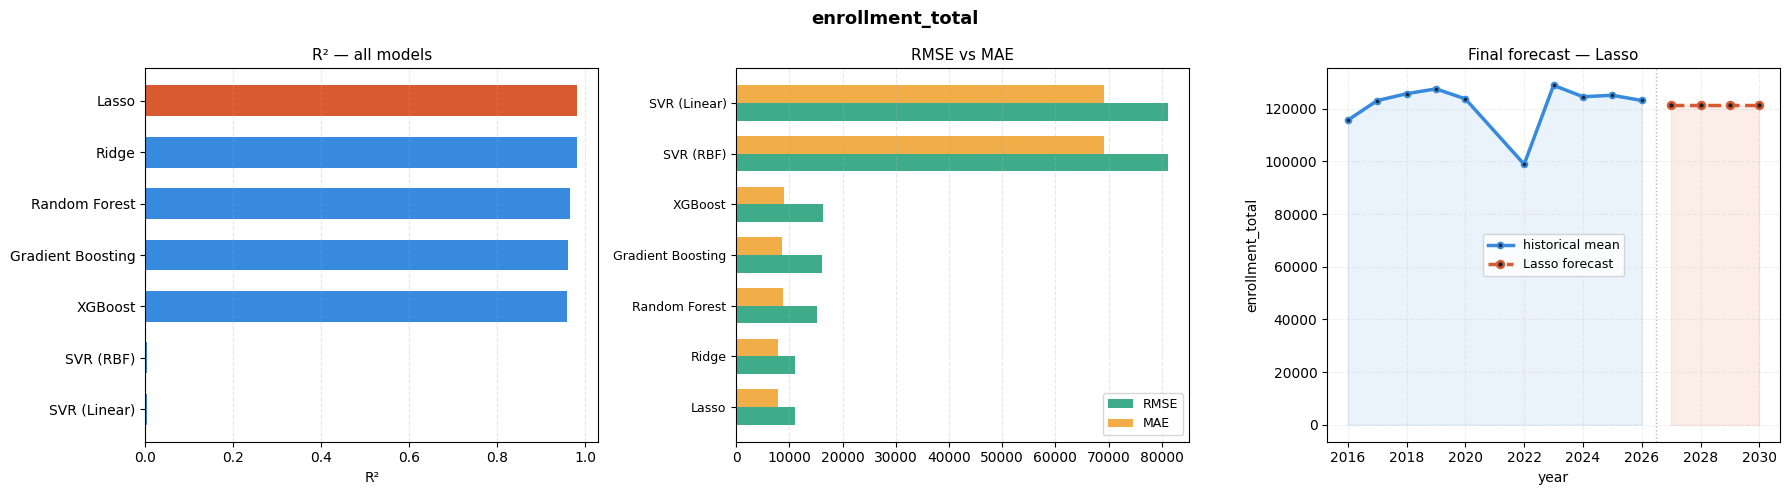

>>> DROPOUT RATE

  TARGET: avg_dropout_rate  |  Val: 2024–2026
            Model      R²   RMSE    MAE
          XGBoost -0.0010 1.7630 1.4728
            Ridge -0.1145 1.8603 1.5561
Gradient Boosting -0.1290 1.8724 1.5093
            Lasso -0.1497 1.8895 1.6122
    Random Forest -0.1873 1.9201 1.6148
     SVR (Linear) -0.2000 1.9303 1.5760
        SVR (RBF) -0.6184 2.2417 1.8071

  ✔ Best model: XGBoost  (R²=-0.001)

  Forecast 2027–2030:
 Year  avg_dropout_rate_forecast
 2027                     9.0805
 2028                     9.1678
 2029                     9.1492
 2030                     9.1904


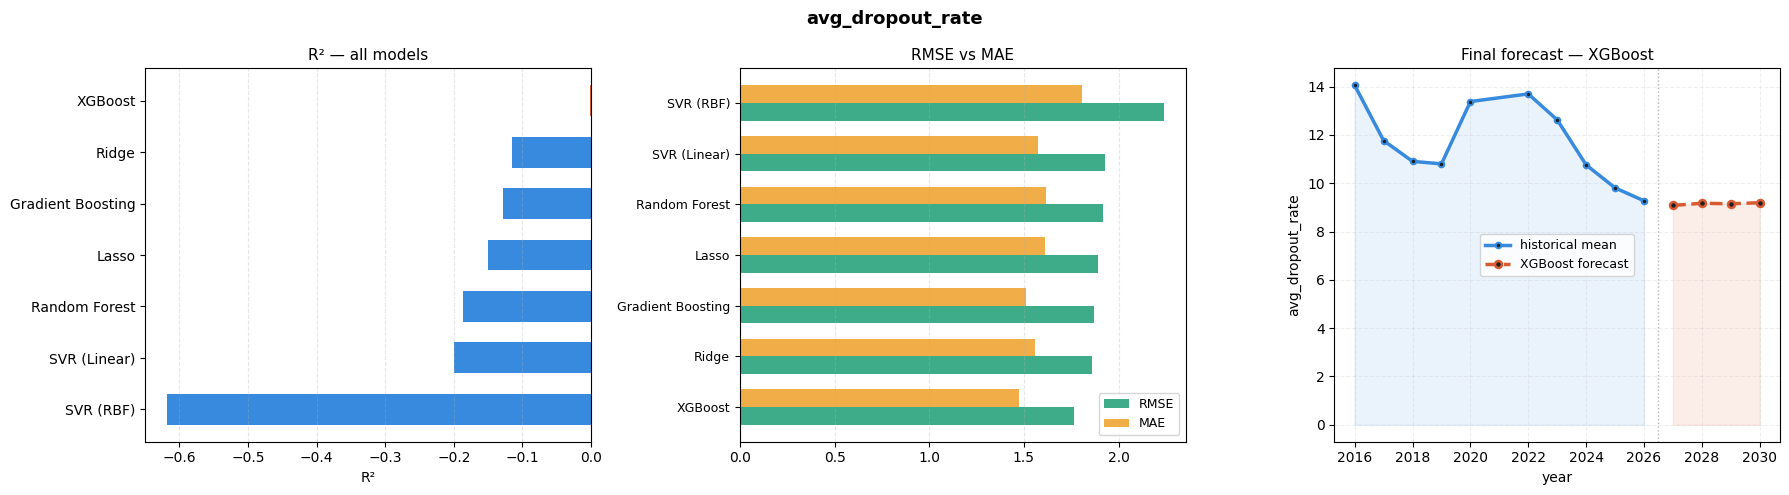

>>> TEACHER QUALITY

  TARGET: teaching_staff_edu_qual_index  |  Val: 2024–2026
            Model      R²   RMSE    MAE
Gradient Boosting  0.5193 0.1139 0.0896
          XGBoost  0.4743 0.1192 0.0932
    Random Forest  0.3461 0.1329 0.1055
        SVR (RBF)  0.2118 0.1459 0.1089
            Ridge -0.0483 0.1683 0.1274
            Lasso -0.0787 0.1707 0.1282
     SVR (Linear) -0.1263 0.1744 0.1337

  ✔ Best model: Gradient Boosting  (R²=0.5193)

  Forecast 2027–2030:
 Year  teaching_staff_edu_qual_index_forecast
 2027                                  3.3345
 2028                                  3.3394
 2029                                  3.3523
 2030                                  3.3315


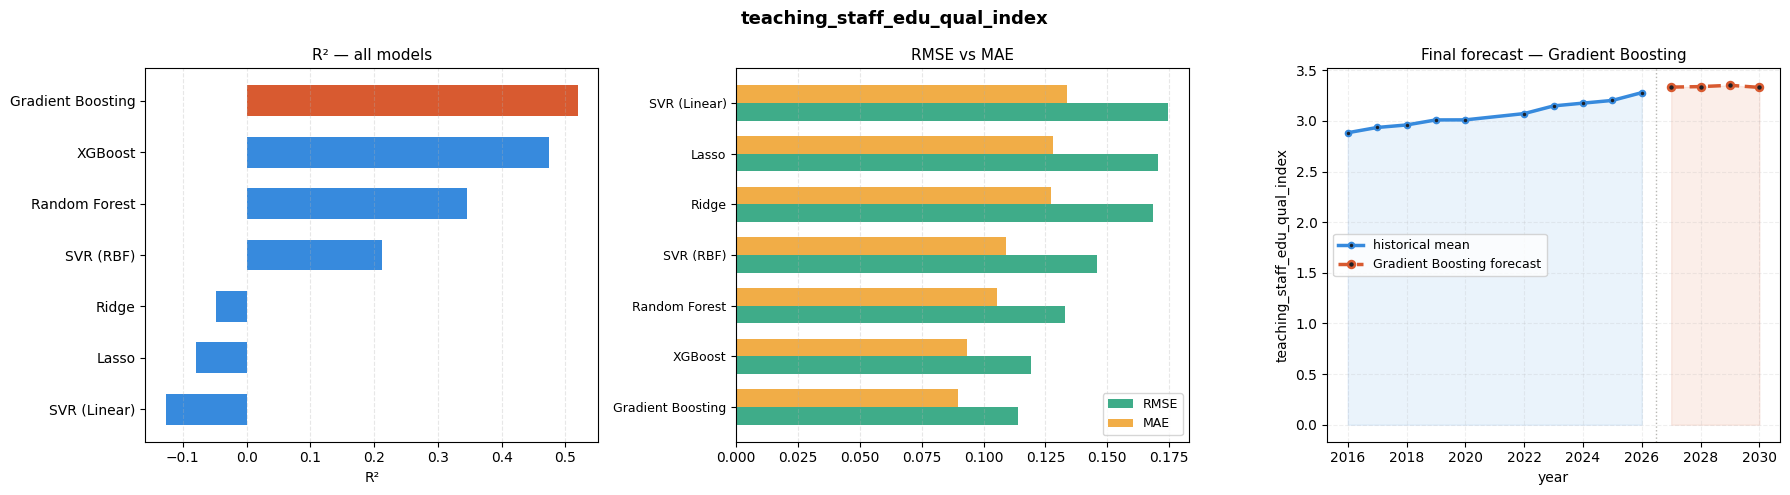

In [29]:
print('>>> ENROLLMENT')
res_e, fut_e, model_e = select_and_forecast(
    df, projected_df, target='enrollment_total',
    features=features_enrollment, log_transform=False)

print('>>> DROPOUT RATE')
res_d, fut_d, model_d = select_and_forecast(
    df, projected_df, target='avg_dropout_rate',
    features=features_dropout, log_transform=True)

print('>>> TEACHER QUALITY')
res_t, fut_t, model_t = select_and_forecast(
    df, projected_df, target='teaching_staff_edu_qual_index',
    features=features_teacher, log_transform=False)


## 8. Fun Comparison: Direct Trend Projection vs. ML Models

How does our complex ML model (trained on many features) compare to a simple "dumb" extrapolation of the target itself?

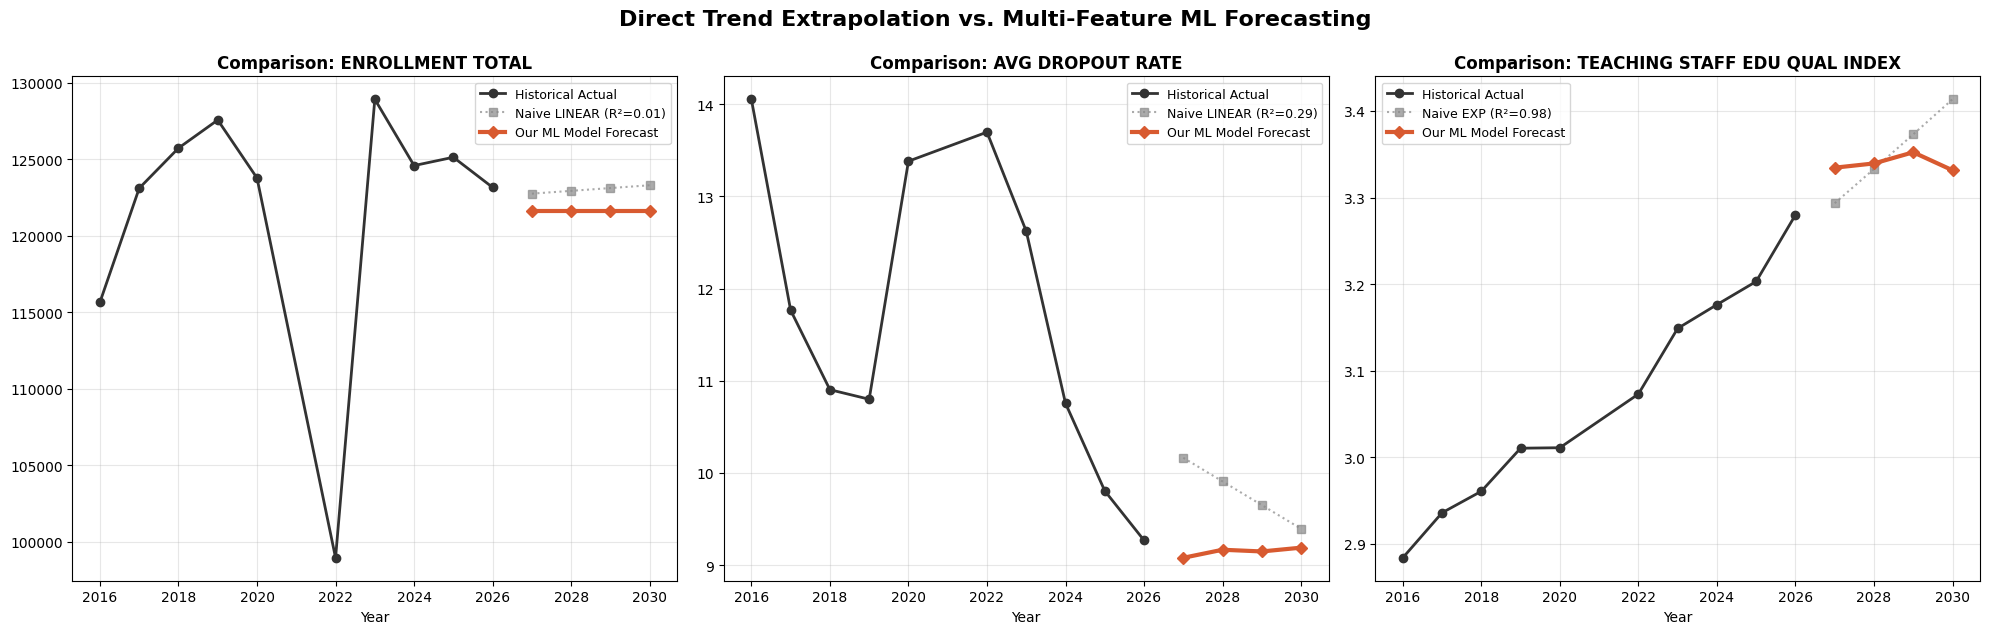

In [30]:
targets = ['enrollment_total', 'avg_dropout_rate', 'teaching_staff_edu_qual_index']
years_future = [2027, 2028, 2029, 2030]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.flatten()

for i, target in enumerate(targets):
    ax = axes[i]
    
    # 1. Get Historical Data
    hist = df.groupby('Year')[target].mean()
    ax.plot(hist.index, hist.values, marker='o', color='#333333', label='Historical Actual', linewidth=2, zorder=5)
    
    # 2. Direct Simple Projection (The "Naive" Way)
    fit_name, pred_fn, r2 = _fit_candidates(hist.index.values, hist.values)
    direct_preds = pred_fn(np.array(years_future, dtype=float))
    ax.plot(years_future, direct_preds, marker='s', color='#888888', linestyle=':', 
            label=f'Naive {fit_name.upper()} (R²={r2:.2f})', alpha=0.7)
    
    # 3. Our ML Forecast Results (The "Smart" Way)
    ml_df = None
    if target == 'enrollment_total': ml_df = fut_e
    elif target == 'avg_dropout_rate': ml_df = fut_d
    elif target == 'teaching_staff_edu_qual_index': ml_df = fut_t
    
    if ml_df is not None:
        ax.plot(ml_df['Year'], ml_df[f'{target}_forecast'], marker='D', color='#D85A30', 
                linewidth=3, label='Our ML Model Forecast')
        
    ax.set_title(f"Comparison: {target.replace('_', ' ').upper()}", fontweight='bold')
    ax.set_xlabel("Year")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("Direct Trend Extrapolation vs. Multi-Feature ML Forecasting", fontsize=16, fontweight='bold', y=1.05)
plt.show()